In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE


count     590.000000
mean       71.103390
std       241.850565
min         0.000000
25%         2.000000
50%         6.000000
75%         9.000000
max      1429.000000
dtype: float64
----------------------------------------------------------------------------------------------------


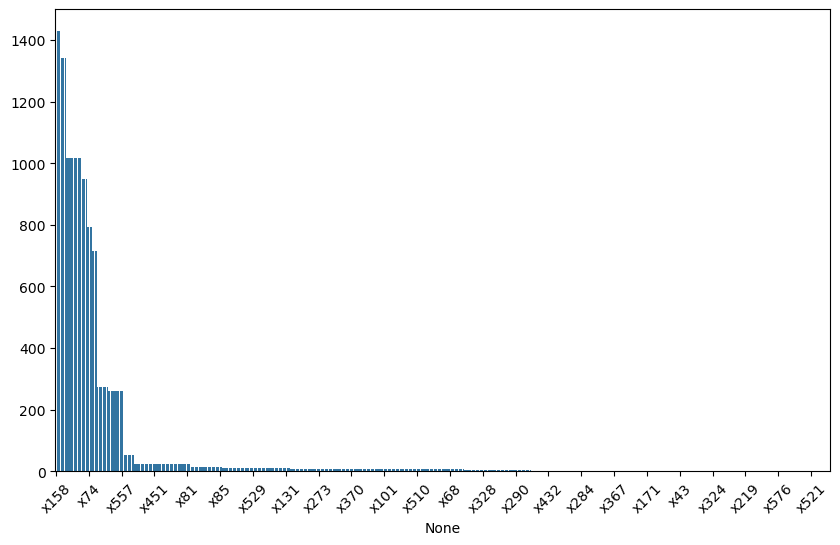

In [5]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum().sort_values(ascending=False)
print(na_counts.describe().T)
print('--'*50)
plt.figure(figsize=(10, 6))
sns.barplot(x=na_counts.index, y=na_counts.values)
plt.xticks(range(0, len(na_counts), 25), na_counts.index[::25], rotation=45)
plt.show()

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


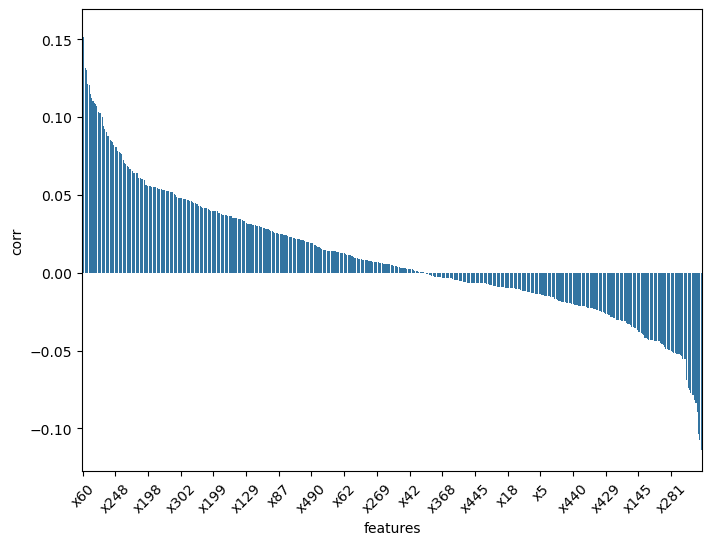

In [10]:
xy_corr = X.corrwith(y).dropna().sort_values(ascending=False)
xy_corr_df = xy_corr.reset_index()
xy_corr_df.columns = ['features', 'corr']
plt.figure(figsize=(8, 6))
sns.barplot(data=xy_corr_df, x='features', y='corr')
plt.xticks(range(0, len(xy_corr), 25), xy_corr.index[::25], rotation=45)
plt.show()

<Axes: >

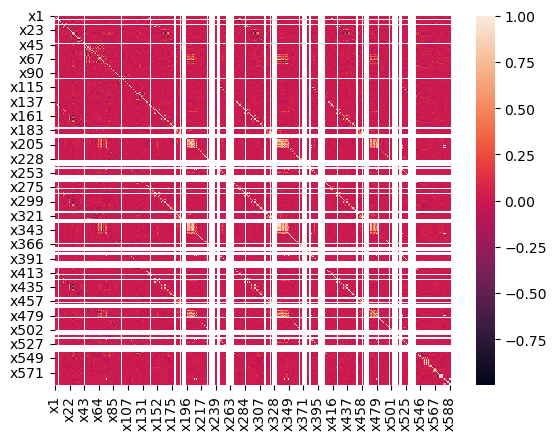

In [19]:
sns.heatmap(X.corr())

---
---

## 中興Paper 

1. 去掉na值超過1000筆的欄位(columns, 也就是p)
2. knn填補剩下的na, 用n_neighbors=10, weights='distance'
3. 隨機森林特徵選擇前140筆重要值較大的特徵
4. SMOTE over resampling, fail:pass=1:1
5. training, testing split拆8:2再做決策樹(CART) modeling (criterion='gini', max_depth=6)

#### 結果: FAR=21.9% 與paper的結果 FAR=9.22% 相差甚遠

In [22]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)
na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()

knn = KNNImputer(n_neighbors=10, weights='distance')
X_imputed = pd.DataFrame(knn.fit_transform(X), columns=X.columns, index=X.index)

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_imputed, y)
important_ = pd.Series(rf.feature_importances_, index=X_imputed.columns)
top140_features = important_.sort_values(ascending=False).head(140).index.tolist()

X_top140 = X_imputed[top140_features].copy()

smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)

X_balanced, y_balanced = smote.fit_resample(X_top140, y)

X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

dtc = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=6)
dtc_model =dtc.fit(X_train, y_train)

dtc_y_pred = dtc_model.predict(X_test)
dtc_y_prob = dtc_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, dtc_y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
cm_df = pd.DataFrame(cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"])
print(cm_df)

TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
FAR = FP/(FP+TN) if (FP+TN) > 0 else np.nan
TP = TP/(TP+FN) if (TP+FN) > 0 else np.nan
print("TP = ", round(TP*100, 2), "%")
print("FAR = ", round(FAR*100, 2), "%")

        Pred 0  Pred 1
True 0     239      67
True 1      43     237
TP =  84.64 %
FAR =  21.9 %


### 單變量logistic做feature selection

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


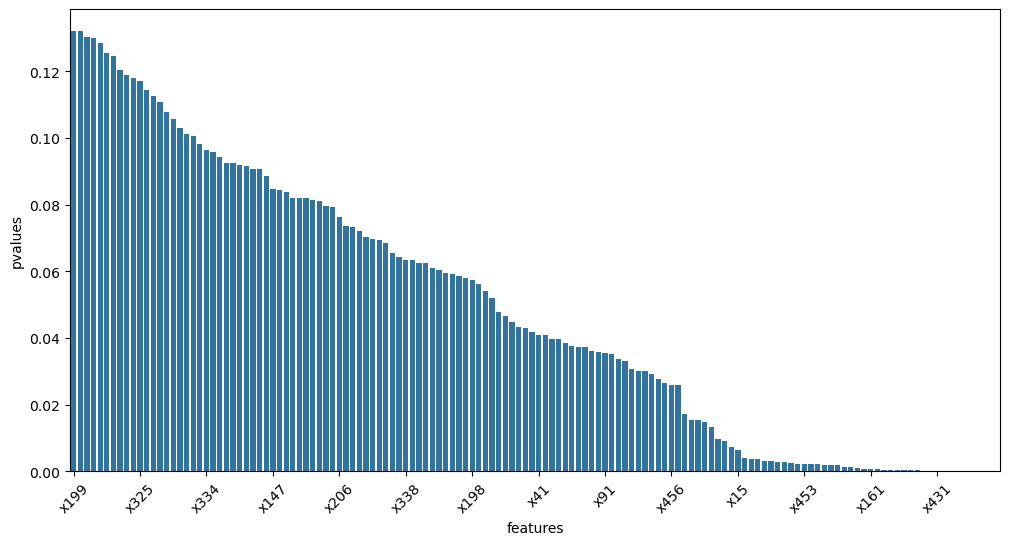

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)
na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()

knn = KNNImputer(n_neighbors=10, weights='distance')
X_imputed = pd.DataFrame(knn.fit_transform(X), columns=X.columns, index=X.index)

p_values = {}
for col in X_imputed.columns:
    if X_imputed[col].nunique()<2:
        continue
    Xi = sm.add_constant(X_imputed[[col]], has_constant='add')
    try:
        fit = sm.GLM(y, Xi, family=sm.families.Binomial()).fit(disp=0)
        p_values[col] = float(fit.pvalues[col])
    except Exception:
        p_values[col] = 1

pvals = pd.Series(p_values).replace([np.inf, -np.inf], np.nan).dropna()
top140_features = pvals.sort_values(ascending=True).head(140).index.tolist()

to_plot = pvals[top140_features].sort_values(ascending=False)
to_plot_df = to_plot.reset_index()
to_plot_df.columns = ['features', 'pvalues']

plt.figure(figsize=(12, 6))
sns.barplot(data=to_plot_df, x='features', y='pvalues')
plt.xticks(range(0, len(to_plot), 10), to_plot.index[::10], rotation=45)
plt.show()

### 單變量logistic做feature selection
### 降低一些FAR =  18.95 %

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)
na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()

knn = KNNImputer(n_neighbors=10, weights='distance')
X_imputed = pd.DataFrame(knn.fit_transform(X), columns=X.columns, index=X.index)

p_values = {}
for col in X_imputed.columns:
    if X_imputed[col].nunique()<2:
        continue
    Xi = sm.add_constant(X_imputed[[col]], has_constant='add')
    try:
        fit = sm.GLM(y, Xi, family=sm.families.Binomial()).fit(disp=0)
        p_values[col] = float(fit.pvalues[col])
    except Exception:
        p_values[col] = 1

pvals = pd.Series(p_values).replace([np.inf, -np.inf], np.nan).dropna()
top140_features = pvals.sort_values(ascending=True).head(140).index.tolist()
X_top140 = X_imputed[top140_features].copy()

smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)

X_balanced, y_balanced = smote.fit_resample(X_top140, y)

X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

dtc = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=6)
dtc_model =dtc.fit(X_train, y_train)

dtc_y_pred = dtc_model.predict(X_test)
dtc_y_prob = dtc_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, dtc_y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
cm_df = pd.DataFrame(cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"])
print(cm_df)

TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
FAR = FP/(FP+TN) if (FP+TN) > 0 else np.nan
sensitivity = TP/(TP+FN) if (TP+FN) > 0 else np.nan
print("sensitivity = ", round(sensitivity*100, 2), "%")
print("FAR = ", round(FAR*100, 2), "%")


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


        Pred 0  Pred 1
True 0     248      58
True 1      31     249
TP =  88.93 %
FAR =  18.95 %


---
---

## 後面才拆8:2 再training data上做SMOTE

In [9]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)
na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()

knn = KNNImputer(n_neighbors=10, weights='distance')
X_imputed = pd.DataFrame(knn.fit_transform(X), columns=X.columns, index=X.index)

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_imputed, y)
important_ = pd.Series(rf.feature_importances_, index=X_imputed.columns)
top140_features = important_.sort_values(ascending=False).head(140).index.tolist()

X_top140 = X_imputed[top140_features].copy()

X_train, X_test, y_train, y_test = train_test_split(X_top140, y, test_size=0.2, stratify=y,random_state=42)

smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)

X_balanced, y_balanced = smote.fit_resample(X_train, y_train)

dtc = DecisionTreeClassifier(random_state=42)
dtc_model =dtc.fit(X_balanced, y_balanced)

dtc_y_pred = dtc_model.predict(X_test)
dtc_y_prob = dtc_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, dtc_y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
cm_df = pd.DataFrame(cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"])
print(cm_df)

TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
FAR = FP/(FP+TN) if (FP+TN) > 0 else np.nan
sensitivity = TP/(TP+FN) if (TP+FN) > 0 else np.nan
print("sensitivity = ", round(sensitivity*100, 2), "%")
print("FAR = ", round(FAR*100, 2), "%")


        Pred 0  Pred 1
True 0     262      31
True 1      15       6
sensitivity =  28.57 %
FAR =  10.58 %


---
---

1. Drop NA
2. KNN imputation
3. 隨機森林特徵選擇前140
4. 5-folds cross validation: 
    1. 依類別比例分成5折(每折獨立)，每次以1折作testing、其餘4折training
    2. 每次的training都會做smote over-resampling
5. 釋出metrics, 做model evaluation

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)
na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()

knn = KNNImputer(n_neighbors=10, weights='distance')
X_imputed = pd.DataFrame(knn.fit_transform(X), columns=X.columns, index=X.index)

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_imputed, y)
important_ = pd.Series(rf.feature_importances_, index=X_imputed.columns)
top140_features = important_.sort_values(ascending=False).head(140).index.tolist()

X_top140 = X_imputed[top140_features].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TP, FN],[FP, TN]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_top140, y), start=1):
    X_tr, X_te = X_top140.iloc[tr_idx], X_top140.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr, y_tr)

    # lr = LinearRegression()
    # lr.fit(X_balanced, y_balanced)
    # y_hat = lr.predict(X_te)
    # y_hat = np.clip(y_hat, 0, 1)
    # y_pred = (y_hat>=0.5).astype(int) # >=0.5 -> 1(fail); <0.5 -> -1(pass)

    # clf = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
    # rfc = RandomForestClassifier(n_estimators=500, random_state=42)
    xgbc = XGBClassifier(objective='binary:logistic', eval_metric='auc', n_estimators=500, learning_rate=0.01, subsample=0.8, tree_method='hist', n_jobs=-1, random_state=42)
    xgbc.fit(X_balanced, y_balanced)
    y_pred = xgbc.predict(X_te)

    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 5 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

### Linear regression
fold=1, acc=0.7962, FAR=0.1809
sensitivy =  47.62 %
specificity =  81.91 %
GM =  62.45 %
----------------------------------------
fold=2, acc=0.8121, FAR=0.1638
sensitivy =  47.62 %
specificity =  83.62 %
GM =  63.1 %
----------------------------------------
fold=3, acc=0.7827, FAR=0.2048
sensitivy =  60.0 %
specificity =  79.52 %
GM =  69.07 %
----------------------------------------
fold=4, acc=0.7827, FAR=0.1815
sensitivy =  28.57 %
specificity =  81.85 %
GM =  48.36 %
----------------------------------------
fold=5, acc=0.7955, FAR=0.1849
sensitivy =  52.38 %
specificity =  81.51 %
GM =  65.34 %
----------------------------------------
[Mean over 5 folds]
acc=0.7939, FAR=0.1832
sensitivy =  47.24 %
specificity =  81.68 %
GM =  61.67 %

### XGboost

fold=1, acc=0.8917, FAR=0.0546
sensitivy =  14.29 %
specificity =  94.54 %
GM =  36.75 %
----------------------------------------
fold=2, acc=0.9108, FAR=0.0307
sensitivy =  9.52 %
specificity =  96.93 %
GM =  30.38 %
----------------------------------------
fold=3, acc=0.9042, FAR=0.0512
sensitivy =  25.0 %
specificity =  94.88 %
GM =  48.7 %
----------------------------------------
fold=4, acc=0.9105, FAR=0.0308
sensitivy =  9.52 %
specificity =  96.92 %
GM =  30.38 %
----------------------------------------
fold=5, acc=0.9201, FAR=0.0274
sensitivy =  19.05 %
specificity =  97.26 %
GM =  43.04 %
----------------------------------------
[Mean over 5 folds]
acc=0.9075, FAR=0.0389
sensitivy =  15.48 %
specificity =  96.11 %
GM =  37.85 %

---
---

## 先分成train, test data, 再在train data做pre-processing並modeling, 最後在test datt做test, 總共5次(5-folds)取平均
### 隨機森林feature selection

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)
na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    TP = TP/(TP+FN) if (TP+FN)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
    rf.fit(X_tr_imputed, y_tr)
    important_ = pd.Series(rf.feature_importances_, index=X_tr_imputed.columns)
    top140_features = important_.sort_values(ascending=False).head(140).index.tolist()

    X_tr_top140 = X_tr_imputed[top140_features].copy()
    X_te_top140 = X_te_imputed[top140_features].copy()

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr_top140, y_tr)

    # lr = LinearRegression()
    # lr.fit(X_balanced, y_balanced)
    # y_hat = lr.predict(X_te_top140)
    # y_hat = np.clip(y_hat, 0, 1)
    # y_pred = (y_hat>=0.5).astype(int) # >=0.5 -> 1(fail); <0.5 -> -1(pass)

    # clf = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
    # rfc = RandomForestClassifier(n_estimators=500, random_state=42)
    xgbc = XGBClassifier(objective='binary:logistic', eval_metric='auc', n_estimators=500, learning_rate=0.01, subsample=0.8, tree_method='hist', n_jobs=-1, random_state=42)
    xgbc.fit(X_balanced, y_balanced)
    y_pred = xgbc.predict(X_te_top140)

    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 5 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

### Linear regression
fold=1, acc=0.8127, FAR=0.1617
sensitivy =  43.75 %
specificity =  83.83 %
GM =  60.56 %
----------------------------------------
fold=2, acc=0.7849, FAR=0.1872
sensitivy =  37.5 %
specificity =  81.28 %
GM =  55.21 %
----------------------------------------
fold=3, acc=0.7888, FAR=0.1957
sensitivy =  56.25 %
specificity =  80.43 %
GM =  67.26 %
----------------------------------------
fold=4, acc=0.7800, FAR=0.2094
sensitivy =  62.5 %
specificity =  79.06 %
GM =  70.29 %
----------------------------------------
fold=5, acc=0.7840, FAR=0.1838
sensitivy =  31.25 %
specificity =  81.62 %
GM =  50.5 %
----------------------------------------
[Mean over 5 folds]
acc=0.7901, FAR=0.1876
sensitivy =  46.25 %
specificity =  81.24 %
GM =  60.77 %

### XGboost

fold=1, acc=0.9044, FAR=0.0340
sensitivy =  0.0 %
specificity =  96.6 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9044, FAR=0.0426
sensitivy =  12.5 %
specificity =  95.74 %
GM =  34.59 %
----------------------------------------
fold=3, acc=0.9124, FAR=0.0383
sensitivy =  18.75 %
specificity =  96.17 %
GM =  42.46 %
----------------------------------------
fold=4, acc=0.9320, FAR=0.0299
sensitivy =  37.5 %
specificity =  97.01 %
GM =  60.31 %
----------------------------------------
fold=5, acc=0.9040, FAR=0.0385
sensitivy =  6.25 %
specificity =  96.15 %
GM =  24.51 %
----------------------------------------
[Mean over 5 folds]
acc=0.9114, FAR=0.0367
sensitivy =  15.0 %
specificity =  96.33 %
GM =  32.38 %

### 單變量 logistic regression feature selection
#### 10-folds

In [5]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)
na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    p_values = {}
    for col in X_tr_imputed.columns:
        if X_tr_imputed[col].nunique()<2:
            continue
        Xi = sm.add_constant(X_tr_imputed[[col]], has_constant='add')
        try:
            fit = sm.GLM(y_tr, Xi, family=sm.families.Binomial()).fit(disp=0)
            p_values[col] = float(fit.pvalues[col])
        except Exception:
            p_values[col] = 1

    pvals = pd.Series(p_values).replace([np.inf, -np.inf], np.nan).dropna()
    top140_features = pvals.sort_values(ascending=True).head(140).index.tolist()

    X_tr_top140 = X_tr_imputed[top140_features].copy()
    X_te_top140 = X_te_imputed[top140_features].copy()

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr_top140, y_tr)

    # lr = LinearRegression()
    # lr.fit(X_balanced, y_balanced)
    # y_hat = lr.predict(X_te_top140)
    # y_hat = np.clip(y_hat, 0, 1)
    # y_pred = (y_hat>=0.5).astype(int) # >=0.5 -> 1(fail); <0.5 -> -1(pass)

    # clf = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
    # rfc = RandomForestClassifier(n_estimators=500, random_state=42)
    xgbc = XGBClassifier(objective='binary:logistic', eval_metric='aucpr', n_estimators=500, learning_rate=0.01, subsample=0.8, tree_method='hist', n_jobs=-1, random_state=42)

    xgbc.fit(X_balanced, y_balanced)
    y_pred = xgbc.predict(X_te_top140)

    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 10 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

fold=1, acc=0.9286, FAR=0.0085
sensitivy =  0.0 %
specificity =  99.15 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9365, FAR=0.0085
sensitivy =  12.5 %
specificity =  99.15 %
GM =  35.21 %
----------------------------------------
fold=3, acc=0.8968, FAR=0.0424
sensitivy =  0.0 %
specificity =  95.76 %
GM =  0.0 %
----------------------------------------
fold=4, acc=0.9120, FAR=0.0342
sensitivy =  12.5 %
specificity =  96.58 %
GM =  34.75 %
----------------------------------------


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


fold=5, acc=0.9360, FAR=0.0342
sensitivy =  50.0 %
specificity =  96.58 %
GM =  69.49 %
----------------------------------------
fold=6, acc=0.9120, FAR=0.0256
sensitivy =  0.0 %
specificity =  97.44 %
GM =  0.0 %
----------------------------------------
fold=7, acc=0.9280, FAR=0.0171
sensitivy =  12.5 %
specificity =  98.29 %
GM =  35.05 %
----------------------------------------
fold=8, acc=0.9040, FAR=0.0427
sensitivy =  12.5 %
specificity =  95.73 %
GM =  34.59 %
----------------------------------------
fold=9, acc=0.9120, FAR=0.0342
sensitivy =  12.5 %
specificity =  96.58 %
GM =  34.75 %
----------------------------------------
fold=10, acc=0.9200, FAR=0.0171
sensitivy =  0.0 %
specificity =  98.29 %
GM =  0.0 %
----------------------------------------
[Mean over 10 folds]
acc=0.9186, FAR=0.0264
sensitivy =  11.25 %
specificity =  97.36 %
GM =  24.38 %
